## Calculating the energy consumption of the English Housing Stock using CUBES with data from Tabula and Hotmaps

### Importing modules

In [27]:
from cubes.construct.extractor import Extractor
from cubes.construct import constants
from cubes.construct.building import Building
from cubes.package.simple_simulation import prepare_simulation
from cubes.package import envconfig
import pandas as pd

import os
from pathlib import Path

### Defining methods

In [44]:
def test_specific_idf(building_code):
    geometry_data = constants.raw_geometry_data[constants.raw_geometry_data['REFERENCE BUILDING CODE'] == building_code]
    systems_data =constants.clean_system_data[constants.clean_system_data['Building typology'] == building_code]
    #print(geometry_data.head())
    #for c in geometry_data.columns:
    #    print(c)
    #print(systems_data.columns)

    #return
    geometry_data = geometry_data.reset_index(drop = True)
    extracted = Extractor(geometry_data, systems_data)

    BC = extracted.create_building_config_object()
    EC = envconfig.EnvConfig(observe_zone_temperature=True,observe_electricity_demand=True,observe_fuel_demand=True,observe_outside_temperature=True)    
    building=Building(BC)
    building.build()
    idf = building.get_idf()

    cwd_path = os.getcwd()
    env_data_path = os.path.join(os.path.join(cwd_path,"cases"), str(building_code))
    print(env_data_path)
    output_directory_path = os.path.join(env_data_path, "output")

    Path(env_data_path).mkdir(parents=True, exist_ok=True)
    Path(output_directory_path).mkdir(parents=True, exist_ok=True)

    idf,weather_file=prepare_simulation(idf,BC,EC)
    
    idf.save(filename=env_data_path + "/building.idf")
    print(weather_file)
    idf.run(
        expandobjects=True,
        readvars=True,
        weather=weather_file,
        output_directory=output_directory_path,
)

    #get results
    results = pd.read_csv(output_directory_path+"/eplusout.csv")
    electricity = results["Whole Building:Facility Total Building Electricity Demand Rate [W](Hourly)"].sum()
    gas = results["MAIN BOILER:Boiler NaturalGas Rate [W](Hourly)"].sum()
    return {"gas":gas, "electricity":electricity, "floor_area":building.get_floor_area()}


def run_archetypes(codes):
    data = {'Code': [], 'Gas [Wh]': [], 'Electricity [Wh]': [], 'Floor Area [m2]':[]}

    #counter = 0
    for code in codes:
        results = test_specific_idf(code)
        
        #ht = pd.read_html("/workspaces/CUBES/exp/jack/EHS-energy-comparison/input_case_1/output/eplustbl.htm")[0]
        #energy = ht.iloc[1,1]
        data['Code'].append(code)
        data['Gas [Wh]'].append(results["gas"])
        data['Electricity [Wh]'].append(results["electricity"])
        data['Floor Area [m2]'].append(results["floor_area"])

        #break

    df = pd.DataFrame(data)

    return df

#### Getting the English Archetype codes

In [45]:
#gb_ambience = pd.read_excel('/workspaces/CUBES/exp/jack/Data/UK_Data/GB_Ambience.xlsx')
num_buildings = constants.gb_ambience['BUILDING STOCK SEGMENT NUMBER OF BUILDINGS']
gb_codes = constants.gb_ambience.iloc[:,1]

In [30]:
print(num_buildings)

0     9.000000e+05
1     4.000000e+05
2     7.000000e+05
3     1.162225e+06
4     4.379399e+05
5     4.356808e+05
6     6.825393e+05
7     3.474837e+05
8     5.754619e+05
9     4.254821e+05
10    4.066658e+05
11    2.584603e+06
12    9.739085e+05
13    2.016979e+06
14    1.528402e+06
15    6.906353e+05
16    1.413108e+06
17    1.196257e+06
18    1.544367e+06
19    2.584603e+06
20    9.739085e+05
21    2.016979e+06
22    1.528402e+06
23    6.906353e+05
24    1.413108e+06
25    1.196257e+06
26    1.544367e+06
Name: BUILDING STOCK SEGMENT NUMBER OF BUILDINGS, dtype: float64


### Running the simulations on the English Housing Stock
The annual energy consumption and code is stored within a dataframe, df

In [46]:
df = run_archetypes(gb_codes)

     REFERENCE BUILDING CODE REFERENCE BUILDING COUNTRY CODE  \
2245                GB-AB-03                             NaN   

     REFERENCE BUILDING USE CODE  REFERENCE BUILDING CONSTRUCTION YEAR LOW  \
2245                         NaN                                       NaN   

      REFERENCE BUILDING CONSTRUCTION YEAR HIGH  \
2245                                        NaN   

      REFERENCE BUILDING MATERIAL COMBINATION CODE  \
2245                                           NaN   

      REFERENCE BUILDING USEFUL FLOOR AREA (m2)  \
2245                                        NaN   

      NUMBER OF REFERENCE BUILDINGS IN THE BUILDING STOCK SEGMENT  \
2245                                                NaN             

      NUMBER OF REFERENCE BUILDING STOREYS  \
2245                                    11   

      REFERENCE BUILDING GROUND FLOOR AREA (m2)  ...  U_Door_1  \
2245                                      316.5  ...       3.0   

      g_gl_n_Window_1  g_gl_n_Wind

EnergyPlus Completed Successfully.


/workspaces/elizabeth-homes/exp/hannes/EHS-energy-comparison/input/weather.epw

/usr/local/EnergyPlus-9-5-0/energyplus --weather /workspaces/elizabeth-homes/exp/hannes/EHS-energy-comparison/input/weather.epw --output-directory /workspaces/elizabeth-homes/exp/hannes/EHS-energy-comparison/cases/GB-AB-03/output --idd /usr/local/EnergyPlus-9-5-0/Energy+.idd --expandobjects --readvars /workspaces/elizabeth-homes/exp/hannes/EHS-energy-comparison/in.idf

ExpandObjects Started.
No expanded file generated.
ExpandObjects Finished. Time:     0.014
EnergyPlus Starting
EnergyPlus, Version 9.5.0-de239b2e5f, YMD=2023.02.27 17:31
Initializing Response Factors
Calculating CTFs for "WALL-CONSTRUCTION"
Calculating CTFs for "ROOF-CONSTRUCTION"
Calculating CTFs for "ROOF-CONSTRUCTION"
Calculating CTFs for "ROOF-CONSTRUCTION"
Calculating CTFs for "GROUNDFLOOR-CONSTRUCTION"
Calculating CTFs for "FLOOR-CONSTRUCTION"
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module A

In [20]:
df["Number of Buildings"] = num_buildings
df

,Code,Gas [Wh],Electricity [Wh],Floor Area [m2],Number of Buildings
0,GB-AB-03,1.438330e+08,2.168216e+08,3481.50,9.000000e+05
1,GB-AB-04,9.494853e+07,2.915672e+08,4681.69,4.000000e+05
2,GB-AB-07,6.605349e+07,2.583138e+08,4147.74,7.000000e+05
3,GB-MFH-01,2.159656e+07,2.785891e+07,447.33,1.162225e+06
4,GB-MFH-02,2.230699e+07,3.142184e+07,504.54,4.379399e+05
5,GB-MFH-03,1.089928e+07,2.926951e+07,469.98,4.356808e+05
6,GB-MFH-04,1.246696e+07,3.643275e+07,585.00,6.825393e+05
7,GB-MFH-05,9.828129e+06,4.112416e+07,660.33,3.474837e+05
8,GB-MFH-06,1.010222e+07,4.490196e+07,720.99,5.754619e+05
9,GB-MFH-07,1.263343e+07,6.404877e+07,1028.43,4.254821e+05


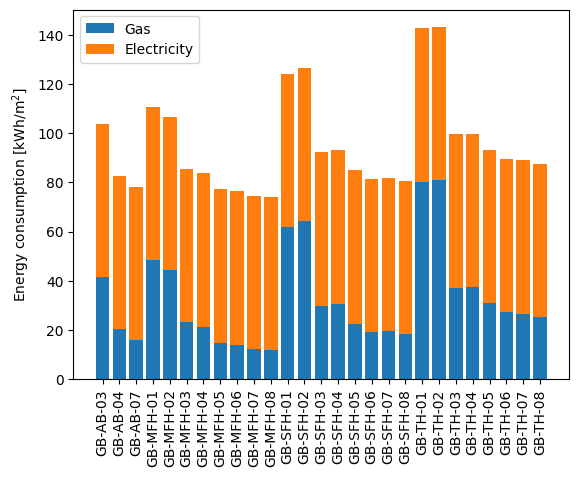

In [17]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots()
ax.bar(df["Code"],df["Gas [Wh]"]/df["Floor Area [m2]"]/1000,label="Gas")
ax.bar(df["Code"],df["Electricity [Wh]"]/df["Floor Area [m2]"]/1000,bottom=df["Gas [Wh]"]/df["Floor Area [m2]"]/1000,label='Electricity')
ax.set_ylabel("Energy consumption [$\mathregular{kWh/m}^2$]")
plt.xticks(rotation='vertical')
ax.legend()


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26],
 [Text(0, 0, 'GB-AB-03'),
  Text(1, 0, 'GB-AB-04'),
  Text(2, 0, 'GB-AB-07'),
  Text(3, 0, 'GB-MFH-01'),
  Text(4, 0, 'GB-MFH-02'),
  Text(5, 0, 'GB-MFH-03'),
  Text(6, 0, 'GB-MFH-04'),
  Text(7, 0, 'GB-MFH-05'),
  Text(8, 0, 'GB-MFH-06'),
  Text(9, 0, 'GB-MFH-07'),
  Text(10, 0, 'GB-MFH-08'),
  Text(11, 0, 'GB-SFH-01'),
  Text(12, 0, 'GB-SFH-02'),
  Text(13, 0, 'GB-SFH-03'),
  Text(14, 0, 'GB-SFH-04'),
  Text(15, 0, 'GB-SFH-05'),
  Text(16, 0, 'GB-SFH-06'),
  Text(17, 0, 'GB-SFH-07'),
  Text(18, 0, 'GB-SFH-08'),
  Text(19, 0, 'GB-TH-01'),
  Text(20, 0, 'GB-TH-02'),
  Text(21, 0, 'GB-TH-03'),
  Text(22, 0, 'GB-TH-04'),
  Text(23, 0, 'GB-TH-05'),
  Text(24, 0, 'GB-TH-06'),
  Text(25, 0, 'GB-TH-07'),
  Text(26, 0, 'GB-TH-08')])

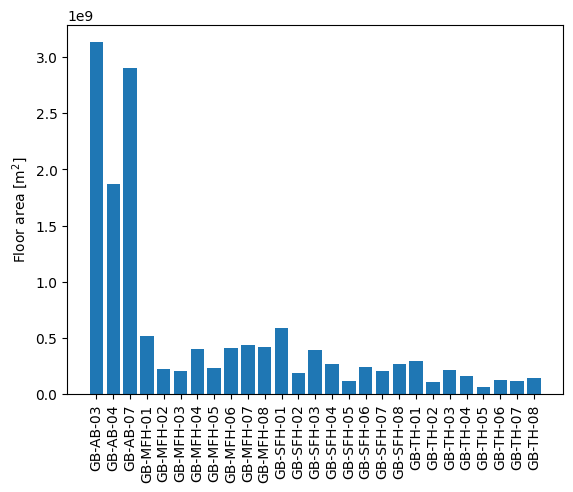

In [26]:
fig,ax = plt.subplots()
ax.bar(df["Code"],df["Number of Buildings"]*df["Floor Area [m2]"])
ax.set_ylabel("Floor area [$\mathregular{m}^2$]")
plt.xticks(rotation='vertical')


#### Adding information to the dataframe
Information like the number of buildings, total energy consumption and tabula's estimate

In [13]:
df = pd.concat([df, num_buildings], axis=1)
df['Energy'] = pd.to_numeric(df['Energy'])
df['Total Energy'] = df['Energy']*df['BUILDING STOCK SEGMENT NUMBER OF BUILDINGS']

KeyError: 'Energy'

In [ ]:
tabula = {'Floor_Area / m2':[3362, 4357, 4045, 425, 481, 447, 559, 633, 693, 994, 994,
                             198, 153, 134, 123, 127, 141, 149, 149, 105, 93, 88, 85, 
                             74, 80, 98, 98], 
                             
        'Primary_Energy / kWh/m2' :[387.8, 307.9, 78.3, 423.5, 441.1, 437.8, 375.7, 
                                    318.7, 306.9, 89.8, 84.6, 228.3, 233.5, 231.7, 
                                    221.6, 194.6, 180.0, 97.6, 92.9, 238.5, 246.5, 
                                    238.6, 218.9, 205.9, 198.6, 99.4, 94.1]}

tabula_df = pd.DataFrame(tabula)

In [ ]:
tabula_df['Total Energy / kWh'] = (tabula_df['Floor_Area / m2']*tabula_df['Primary_Energy / kWh/m2'])
tabula_df['num_buildings'] = df['BUILDING STOCK SEGMENT NUMBER OF BUILDINGS']
tabula_df['stock_energy_estimate'] = tabula_df['Total Energy / kWh']*tabula_df['num_buildings']

df['Tabula Estimate'] = tabula_df['stock_energy_estimate']
df['cumsum_Tabula'] = df['TABULA / TWh'].cumsum()
df['cumsum_CUBES'] = df['CUBES / TWh'].cumsum()
df['Total Energy / kWh'] = df['Total Energy']*277.8

df = df.rename(columns ={'Energy':'Energy / GJ','Total Energy': 'CUBES / GJ','Total Energy / kWh': 'CUBES / TWh', 'Tabula Estimate': 'TABULA / TWh'})


In [ ]:
cwd_path = os.getcwd()
output_directory_path = os.path.join(cwd_path, "results")
df.to_csv('/workspaces/CUBES/exp/jack/EHS-energy-comparison/results/cubes_tabula_comparison.csv')

#### Importing previously determined results

In [ ]:
df = pd.read_csv('/workspaces/CUBES/exp/jack/Data/cubes_tabula_comparison.csv')

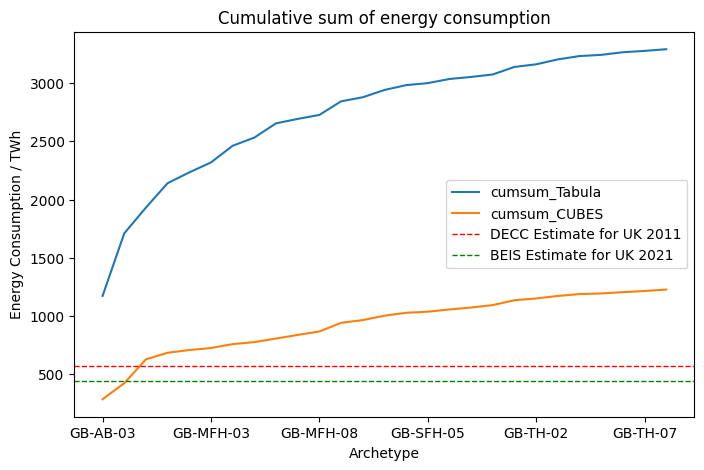

In [ ]:
plot = df.plot.line(x='Code', y=['cumsum_Tabula', 'cumsum_CUBES'], figsize=(8,5))
plot.axhline(y=571, color= 'red', linewidth=1, linestyle='--', label="DECC Estimate for UK 2011")
plot.axhline(y=438, color= 'green', linewidth=1, linestyle='--', label="BEIS Estimate for UK 2021")
plot.set_title('Cumulative sum of energy consumption')

plot.set_ylabel('Energy Consumption / TWh')
plot.set_xlabel('Archetype')
plot.legend()



Text(0.5, 1.0, 'Comparison between CUBES and Tabula archetype energy consumption')

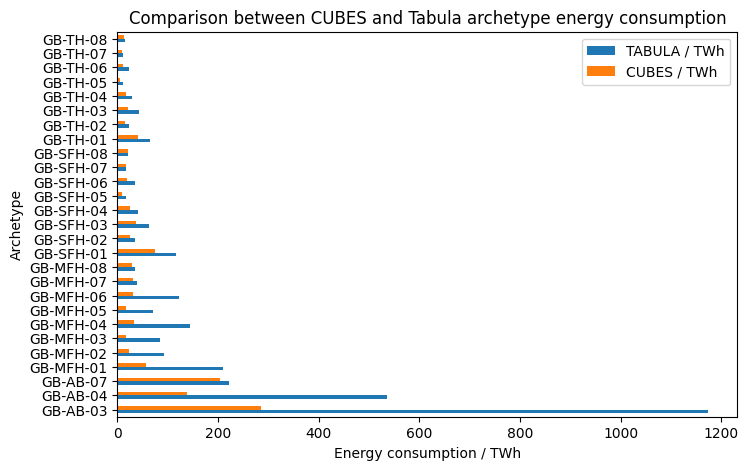

In [ ]:
sp = df.plot.barh(x='Code', y=['TABULA / TWh', 'CUBES / TWh'], figsize=(8,5))
sp.set_xlabel('Energy consumption / TWh')
sp.set_ylabel('Archetype')
sp.set_title('Comparison between CUBES and Tabula archetype energy consumption')